# 전국 지역 CCTV 정보

In [2]:
!pip install matplotlib seaborn

In [3]:
#라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics
import platform
import os

# 한글 폰트 설정
# Windows
# plt.rcParams['font.family'] = 'Malgun Gothic'

# Mac 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

#Seaborn 기본 스타일 설정
sns.set_theme(style="whitegrid", font="AppleGothic" if platform.system()=='Darwin' else "Malgun Gothic")

#데이터 출력
df = pd.read_csv('CCTV정보.csv', encoding='cp949', low_memory=False)

In [4]:
#상위 부분 출력
df.head()

,개방자치단체코드,관리번호,관리기관명,소재지도로명주소,소재지지번주소,설치목적구분,카메라대수,카메라화소수,촬영방면정보,보관일수,설치연월,관리기관전화번호,WGS84위도,WGS84경도,데이터기준일자,데이터갱신구분,데이터갱신시점,최종수정시점
0,3000000,202630000000800340,서울특별시 종로구청,NaN,서울특별시 종로구 사직동 9-2,생활방범,2,200.0,360도 전방면,30.0,202405.0,02-2148-3033,37.57515,126.9688,2026-05-18,NaN,2026-05-19 22:58:21,2026-05-18 15:24:17
1,3000000,202630000000800463,서울특별시 종로구청,서울특별시 종로구 북촌로 134-1 (삼청공원),NaN,생활방범,2,200.0,360도 전방면,30.0,202005.0,02-2148-3033,37.58785,126.9843,2026-05-18,NaN,2026-05-19 22:58:23,2026-05-18 15:24:18
2,3000000,202630000000800474,서울특별시 종로구청,서울특별시 종로구 창신6가길 39 (산마루놀이터),NaN,생활방범,2,200.0,360도 전방면,30.0,201811.0,02-2148-3033,37.57569,127.0124,2026-05-18,NaN,2026-05-19 22:58:23,2026-05-18 15:24:18
3,3000000,202630000000800868,서울특별시 종로구청,서울특별시 종로구 지봉로12길 9,NaN,생활방범,3,200.0,360도 전방면,30.0,201612.0,02-2148-3033,37.57707,127.0162,2026-05-18,NaN,2026-05-19 22:58:21,2026-05-18 15:24:21
4,3000000,202630000000800993,서울특별시 종로구청,서울특별시 종로구 난계로29길 49,NaN,생활방범,3,200.0,360도 전방면,30.0,201312.0,02-2148-3033,37.57380,127.0204,2026-05-18,NaN,2026-05-19 22:58:23,2026-05-18 15:24:22


In [5]:
#데이터셋 정보 출력
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 375204 entries, 0 to 375203
Data columns (total 18 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   개방자치단체코드  375204 non-null  int64  
 1   관리번호      375204 non-null  int64  
 2   관리기관명     375204 non-null  str    
 3   소재지도로명주소  217615 non-null  str    
 4   소재지지번주소   307802 non-null  str    
 5   설치목적구분    375204 non-null  str    
 6   카메라대수     375204 non-null  int64  
 7   카메라화소수    300217 non-null  float64
 8   촬영방면정보    195625 non-null  str    
 9   보관일수      313336 non-null  float64
 10  설치연월      215496 non-null  float64
 11  관리기관전화번호  374226 non-null  str    
 12  WGS84위도   375204 non-null  float64
 13  WGS84경도   375204 non-null  float64
 14  데이터기준일자   375204 non-null  str    
 15  데이터갱신구분   259615 non-null  str    
 16  데이터갱신시점   375204 non-null  str    
 17  최종수정시점    375204 non-null  str    
dtypes: float64(5), int64(3), str(10)
memory usage: 51.5 MB


In [6]:
#전체 데이터셋을 테이블 형식으로 보기
df.describe()

,개방자치단체코드,관리번호,카메라대수,카메라화소수,보관일수,설치연월,WGS84위도,WGS84경도
count,3.752040e+05,3.752040e+05,375204.000000,300217.000000,313336.000000,215496.000000,375204.000000,3.752040e+05
mean,4.223892e+06,2.025617e+17,1.853056,212.448569,29.867149,199876.308915,36.534171,4.688781e+02
std,8.021189e+05,1.155168e+14,1.635049,84.199752,2.390362,20040.063388,1.001306,2.089955e+05
min,3.000000e+06,2.020359e+17,0.000000,0.000000,0.000000,2013.000000,13.274990,1.226670e+01
25%,3.470000e+06,2.025351e+17,1.000000,200.000000,30.000000,201612.000000,35.734275,1.269799e+02
50%,4.211000e+06,2.026311e+17,1.000000,200.000000,30.000000,201912.000000,36.779300,1.273234e+02
75%,4.900000e+06,2.026440e+17,3.000000,200.000000,30.000000,202211.000000,37.483481,1.285614e+02
max,6.520000e+06,2.026652e+17,201.000000,1200.000000,180.000000,202608.000000,95.988760,1.280180e+08


In [7]:
#전체 데이터셋에 있는 값들 모음
df.shape

(375204, 18)

In [8]:
#행, 열 중 열에 대한 정보 조회
df.columns

Index(['개방자치단체코드', '관리번호', '관리기관명', '소재지도로명주소', '소재지지번주소', '설치목적구분', '카메라대수',
       '카메라화소수', '촬영방면정보', '보관일수', '설치연월', '관리기관전화번호', 'WGS84위도', 'WGS84경도',
       '데이터기준일자', '데이터갱신구분', '데이터갱신시점', '최종수정시점'],
      dtype='str')

In [9]:
#특정 열의 정보만 추출
df_1 = df[['관리기관명', '소재지도로명주소', '관리기관전화번호']]
df_1

,관리기관명,소재지도로명주소,관리기관전화번호
0,서울특별시 종로구청,NaN,02-2148-3033
1,서울특별시 종로구청,서울특별시 종로구 북촌로 134-1 (삼청공원),02-2148-3033
2,서울특별시 종로구청,서울특별시 종로구 창신6가길 39 (산마루놀이터),02-2148-3033
3,서울특별시 종로구청,서울특별시 종로구 지봉로12길 9,02-2148-3033
4,서울특별시 종로구청,서울특별시 종로구 난계로29길 49,02-2148-3033
...,...,...,...
375199,제주특별자치도 서귀포시 영천동,NaN,064-760-4651
375200,제주특별자치도 서귀포시 동홍동,NaN,064-760-4693
375201,제주특별자치도 서귀포시 대륜동,제주특별자치도 서귀포시 서호로 75,064-760-4762
375202,제주특별자치도 서귀포시 문화예술과,제주특별자치도 서귀포시 월드컵로 33,064-760-2495


In [10]:
#소재지 도로명 주소의 NaN값 삭제
df_2 = df_1.dropna(subset=['소재지도로명주소'])
df_2

,관리기관명,소재지도로명주소,관리기관전화번호
1,서울특별시 종로구청,서울특별시 종로구 북촌로 134-1 (삼청공원),02-2148-3033
2,서울특별시 종로구청,서울특별시 종로구 창신6가길 39 (산마루놀이터),02-2148-3033
3,서울특별시 종로구청,서울특별시 종로구 지봉로12길 9,02-2148-3033
4,서울특별시 종로구청,서울특별시 종로구 난계로29길 49,02-2148-3033
5,서울특별시 종로구청,서울특별시 종로구 숭인동1길 41,02-2148-3033
...,...,...,...
375196,제주특별자치도 서귀포시 영천동,제주특별자치도 서귀포시 상효로 135-1,064-760-4651
375198,제주특별자치도 서귀포시 노인복지과,제주특별자치도 서귀포시 태평로537번길 40-9,064-760-2382
375201,제주특별자치도 서귀포시 대륜동,제주특별자치도 서귀포시 서호로 75,064-760-4762
375202,제주특별자치도 서귀포시 문화예술과,제주특별자치도 서귀포시 월드컵로 33,064-760-2495


In [11]:
#소재지 기준 '서울특별시' 포함하는 행만 남기는 처리
df_3 = df_2[df_2['소재지도로명주소'].str.contains('서울특별시')]
df_3

,관리기관명,소재지도로명주소,관리기관전화번호
1,서울특별시 종로구청,서울특별시 종로구 북촌로 134-1 (삼청공원),02-2148-3033
2,서울특별시 종로구청,서울특별시 종로구 창신6가길 39 (산마루놀이터),02-2148-3033
3,서울특별시 종로구청,서울특별시 종로구 지봉로12길 9,02-2148-3033
4,서울특별시 종로구청,서울특별시 종로구 난계로29길 49,02-2148-3033
5,서울특별시 종로구청,서울특별시 종로구 숭인동1길 41,02-2148-3033
...,...,...,...
58287,서울특별시 송파구청,서울특별시 송파구 오금로 363,02-2147-4657
161943,경기도 하남시청 상수도과,서울특별시 송파구 성내천로 299 일대,031-790-6445
162287,경기도 하남시청 상수도과,서울특별시 강동구 동남로 일대,031-790-6445
177829,연천군 통일평생교육원,서울특별시 동대문구 난계로30길 28,031-839-4672


In [12]:
#시군구 열 추가 소재지전체주소[1] => 구별로 CCTV가 몇개씩 있는가?
df_3.loc[:, '시군구'] = df_3['소재지도로명주소'].str.split().str[1]
df_3

,관리기관명,소재지도로명주소,관리기관전화번호,시군구
1,서울특별시 종로구청,서울특별시 종로구 북촌로 134-1 (삼청공원),02-2148-3033,종로구
2,서울특별시 종로구청,서울특별시 종로구 창신6가길 39 (산마루놀이터),02-2148-3033,종로구
3,서울특별시 종로구청,서울특별시 종로구 지봉로12길 9,02-2148-3033,종로구
4,서울특별시 종로구청,서울특별시 종로구 난계로29길 49,02-2148-3033,종로구
5,서울특별시 종로구청,서울특별시 종로구 숭인동1길 41,02-2148-3033,종로구
...,...,...,...,...
58287,서울특별시 송파구청,서울특별시 송파구 오금로 363,02-2147-4657,송파구
161943,경기도 하남시청 상수도과,서울특별시 송파구 성내천로 299 일대,031-790-6445,송파구
162287,경기도 하남시청 상수도과,서울특별시 강동구 동남로 일대,031-790-6445,강동구
177829,연천군 통일평생교육원,서울특별시 동대문구 난계로30길 28,031-839-4672,동대문구


In [13]:
#~별 => 그룹핑
df_4 = df_3.groupby('시군구').size().reset_index(name='카메라대수')
df_4

,시군구,카메라대수
0,?금호로,1
1,가람길,4
2,강남구,2028
3,강동구,1
4,강서구,1805
...,...,...
476,행당로3길,2
477,행당로5길,2
478,행당로6길,4
479,행당로8길,5


In [14]:
#30개씩만 출력해 이를 chart에 반영하도록
df_top_30 = df_4.sort_values('카메라대수', ascending=False).head(20)

Text(0, 0.5, '카메라 대수')

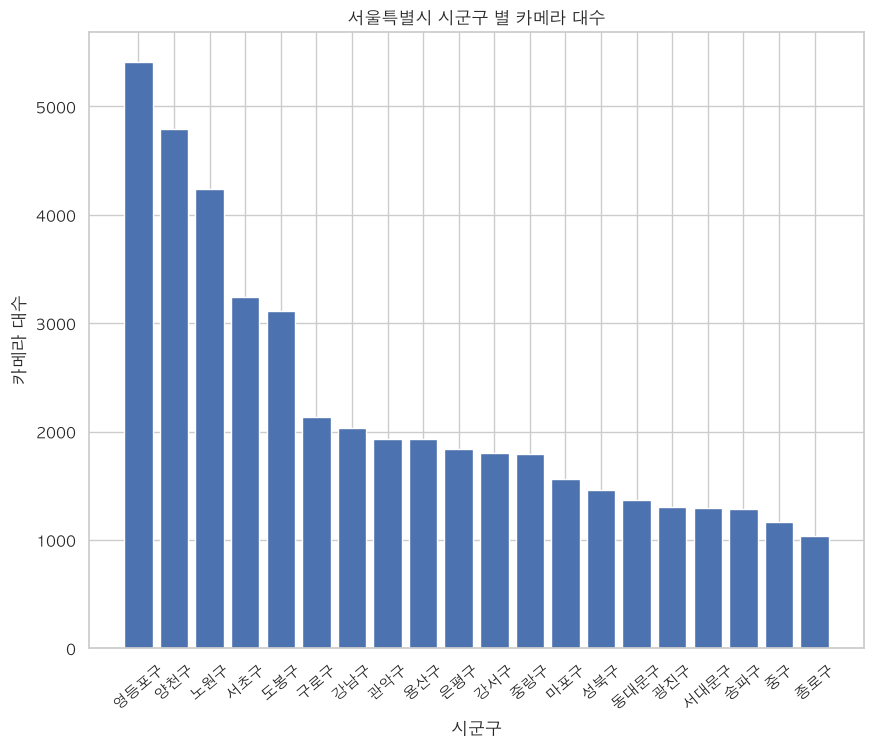

In [15]:
#시각화
#시각화 자료 간격 크기 조절
plt.figure(figsize=(10,8))
#표시할 목록, 색깔 정보 정리
plt.bar(
    df_top_30['시군구'],
    df_top_30['카메라대수'],
    linestyle='-',
    color='b'
)
#시군구 기울기
plt.xticks(rotation=40)
#제목 지정
plt.title('서울특별시 시군구 별 카메라 대수')
#x축
plt.xlabel('시군구')
#y축
plt.ylabel('카메라 대수')

# 최근 4년간 서울특별시 시군구에 새롭게 설치된 카메라

In [24]:
df_4 = pd.to_datetime(df['설치연월'])
recent_date = df_4.max()

df_range = df[df_4 >= recent_date - pd.DateOffset(years=4)]

df_range

,개방자치단체코드,관리번호,관리기관명,소재지도로명주소,소재지지번주소,설치목적구분,카메라대수,카메라화소수,촬영방면정보,보관일수,설치연월,관리기관전화번호,WGS84위도,WGS84경도,데이터기준일자,데이터갱신구분,데이터갱신시점,최종수정시점
0,3000000,202630000000800340,서울특별시 종로구청,NaN,서울특별시 종로구 사직동 9-2,생활방범,2,200.0,360도 전방면,30.0,202405.0,02-2148-3033,37.57515,126.9688,2026-05-18,NaN,2026-05-19 22:58:21,2026-05-18 15:24:17
1,3000000,202630000000800463,서울특별시 종로구청,서울특별시 종로구 북촌로 134-1 (삼청공원),NaN,생활방범,2,200.0,360도 전방면,30.0,202005.0,02-2148-3033,37.58785,126.9843,2026-05-18,NaN,2026-05-19 22:58:23,2026-05-18 15:24:18
2,3000000,202630000000800474,서울특별시 종로구청,서울특별시 종로구 창신6가길 39 (산마루놀이터),NaN,생활방범,2,200.0,360도 전방면,30.0,201811.0,02-2148-3033,37.57569,127.0124,2026-05-18,NaN,2026-05-19 22:58:23,2026-05-18 15:24:18
3,3000000,202630000000800868,서울특별시 종로구청,서울특별시 종로구 지봉로12길 9,NaN,생활방범,3,200.0,360도 전방면,30.0,201612.0,02-2148-3033,37.57707,127.0162,2026-05-18,NaN,2026-05-19 22:58:21,2026-05-18 15:24:21
4,3000000,202630000000800993,서울특별시 종로구청,서울특별시 종로구 난계로29길 49,NaN,생활방범,3,200.0,360도 전방면,30.0,201312.0,02-2148-3033,37.57380,127.0204,2026-05-18,NaN,2026-05-19 22:58:23,2026-05-18 15:24:22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374156,5710000,202357100000800068,청주시청,NaN,충청북도 청주시 서원구 죽림동 416,교통정보수집,1,200.0,360도 전방면,15.0,202103.0,043-201-2834,36.61250,127.4408,2023-04-27,I,2026-05-15 18:45:38,2023-04-28 11:00:09
374157,5710000,202357100000800037,청주시청,NaN,충청북도 청주시 흥덕구 오송읍 만수리 512,교통정보수집,1,40.0,360도 전방면,15.0,200810.0,043-201-2834,36.63140,127.3306,2023-04-27,I,2026-05-15 18:45:38,2023-04-28 11:00:09
374158,5710000,202357100000800001,청주시청,NaN,충청북도 청주시 청원구 내수읍 학평리 281-15,교통정보수집,1,40.0,360도 전방면,15.0,200406.0,043-201-2834,36.72990,127.5420,2023-04-27,I,2026-05-15 18:45:38,2023-04-28 11:00:08
374159,5710000,202357100000800045,청주시청,NaN,충청북도 청주시 흥덕구 비하동 291-2,교통정보수집,1,40.0,360도 전방면,15.0,201310.0,043-201-2834,36.64010,127.4221,2023-04-27,I,2026-05-15 18:45:38,2023-04-28 11:00:09


In [28]:
print(df_range.columns)

Index(['개방자치단체코드', '관리번호', '관리기관명', '소재지도로명주소', '소재지지번주소', '설치목적구분', '카메라대수',
       '카메라화소수', '촬영방면정보', '보관일수', '설치연월', '관리기관전화번호', 'WGS84위도', 'WGS84경도',
       '데이터기준일자', '데이터갱신구분', '데이터갱신시점', '최종수정시점'],
      dtype='str')


In [31]:
#Groupby
df_6 = df_top_30.groupby('시군구').size().reset_index(name='카메라대수')
df_current = df_6.sort_values('카메라대수', ascending=False).head(15)
df_current

,시군구,카메라대수
0,강남구,1
1,강서구,1
18,중구,1
17,종로구,1
16,은평구,1
15,용산구,1
14,영등포구,1
13,양천구,1
12,송파구,1
11,성북구,1


Text(0, 0.5, '카메라 대수')

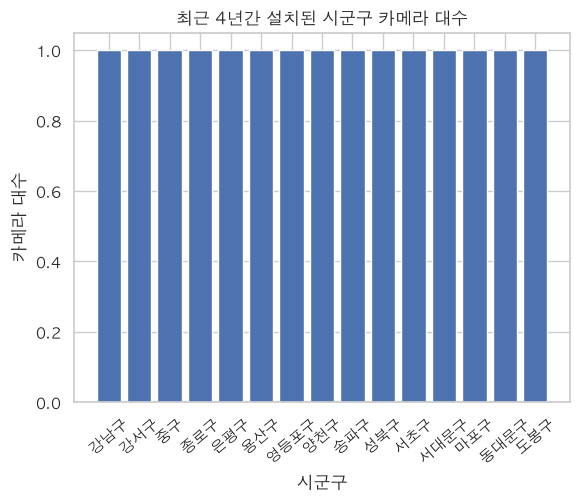

In [32]:
#bar chart
plt.bar(
    df_current['시군구'],
    df_current['카메라대수'],
    linestyle='-',
    color='b'
)
#글자 기울이기
plt.xticks(rotation=40)
#제목
plt.title('최근 4년간 설치된 시군구 카메라 대수')
#x축
plt.xlabel('시군구')
#y축
plt.ylabel('카메라 대수')